# FinSight Alpha - Phase 1: Market Data EDA

This notebook walks through the Phase 1 workflow interactively:

1. Download historical price data for a ticker.
2. Compute returns, cumulative returns, rolling volatility, and drawdown.
3. Visualise each metric.
4. Inspect the summary statistics.

> Run `python main.py` from the project root first if you want the saved CSVs,
> but this notebook downloads its own data so it is fully self-contained.

In [11]:
import sys
from pathlib import Path

# Make the project root importable from within the notebooks/ folder.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd

from src import config
from src.analytics import metrics
from src.data.market_data import download_stock_data
from src.visualization import plots

pd.set_option("display.max_columns", None)
print("Imports ready. Default tickers:", config.ALL_TICKERS)

Imports ready. Default tickers: ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS', 'ICICIBANK.NS', 'AAPL', 'MSFT', 'JPM', 'BLK', 'SPY']


## 1. Download data

Pick any ticker from the universe (or your own). We download adjusted OHLCV data.

In [7]:
TICKER = "MSFT"

df = download_stock_data(TICKER, config.DEFAULT_START_DATE, config.DEFAULT_END_DATE)
df = df.set_index("Date")  # use the date as the index for nicer plots
df.head()

Price,Open,High,Low,Close,Volume,Ticker
Date,,,,,,
2018-01-02,78.864707,79.029524,78.287852,78.699890,22483800,MSFT
2018-01-03,78.800631,79.212677,78.718226,79.066170,26061400,MSFT
2018-01-04,79.285929,80.265679,79.267619,79.762070,21912000,MSFT
2018-01-05,80.265654,80.952390,80.055052,80.750946,23407100,MSFT
2018-01-08,80.760113,81.108063,80.210726,80.833366,22113000,MSFT


## 2. Compute metrics

In [8]:
close = df["Close"]

df["simple_return"] = metrics.calculate_simple_returns(close)
df["log_return"] = metrics.calculate_log_returns(close)
df["cumulative_return"] = metrics.calculate_cumulative_returns(df["simple_return"])
df["rolling_volatility"] = metrics.calculate_rolling_volatility(df["simple_return"])
df["drawdown"] = metrics.calculate_drawdown(close)

df[["Close", "simple_return", "log_return", "cumulative_return", "rolling_volatility", "drawdown"]].tail()

Price,Close,simple_return,log_return,cumulative_return,rolling_volatility,drawdown
Date,,,,,,
2026-05-26,416.029999,-0.006068,-0.006087,4.286284,0.228776,-0.227655
2026-05-27,412.670013,-0.008076,-0.008109,4.243591,0.230104,-0.233893
2026-05-28,426.989990,0.034701,0.034112,4.425547,0.259069,-0.207309
2026-05-29,450.239990,0.054451,0.053020,4.720974,0.316794,-0.164146
2026-06-01,460.519989,0.022832,0.022576,4.851596,0.283365,-0.145061


## 3. Visualise

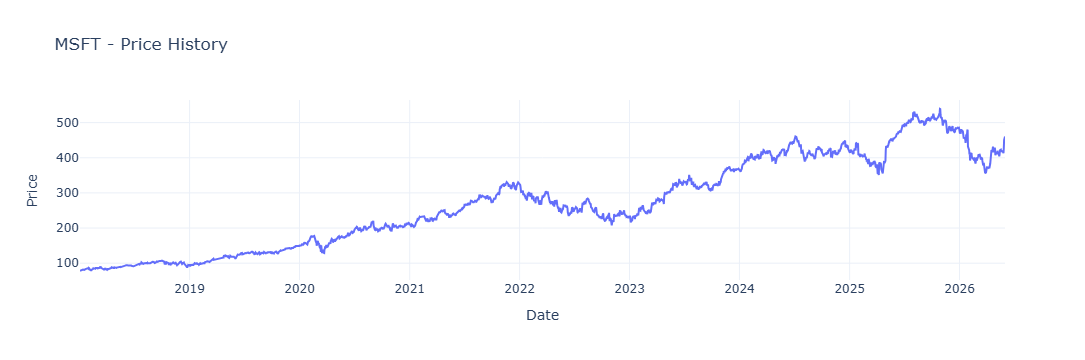

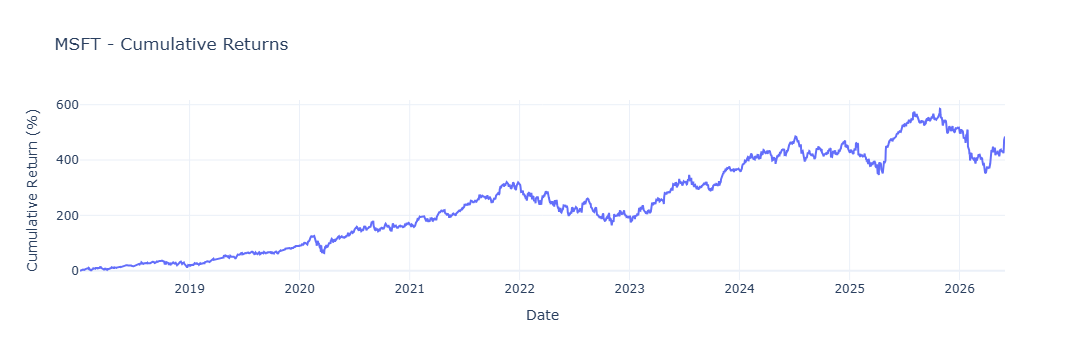

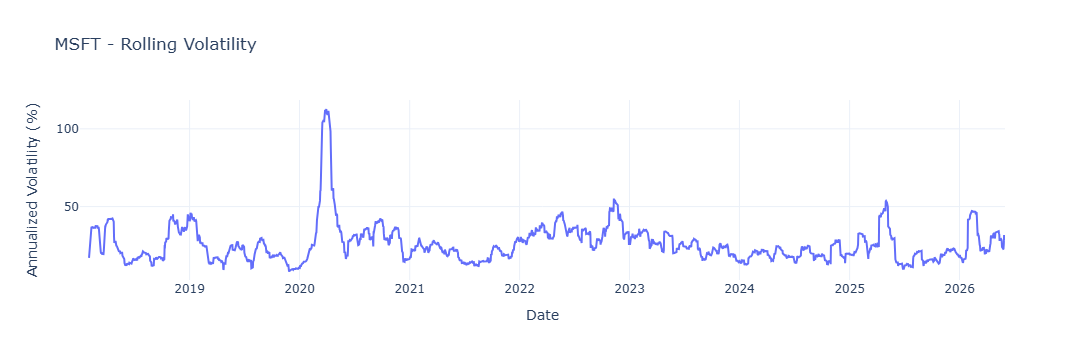

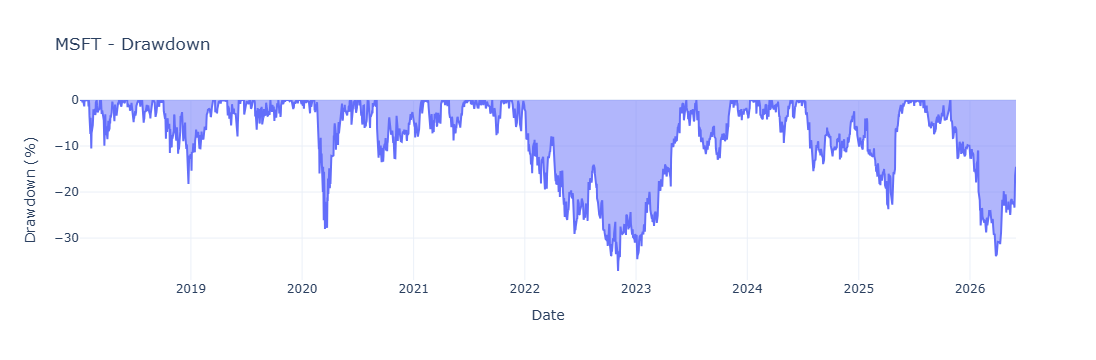

In [9]:
plots.plot_price_history(close, title=f"{TICKER} - Price History").show()
plots.plot_cumulative_returns(df["simple_return"], title=f"{TICKER} - Cumulative Returns").show()
plots.plot_rolling_volatility(df["simple_return"], title=f"{TICKER} - Rolling Volatility").show()
plots.plot_drawdown(close, title=f"{TICKER} - Drawdown").show()

## 4. Summary statistics

In [10]:
stats = metrics.calculate_summary_statistics(close)
pd.Series(stats).to_frame(name=TICKER)

,MSFT
observations,2114.000000
start_price,78.699890
end_price,460.519989
total_return,4.851596
annualized_return,0.234421
annualized_volatility,0.285715
sharpe_ratio,0.820469
max_drawdown,-0.371485
